# DeepSeek‑V4, end to end: paper-aligned visual notebook

This notebook extends the toy walkthrough into a **paper-aligned real scenario**.

We use a small, readable sequence that mimics the paper’s long-context retrieval setting:

> A long document hides a “needle”: `BLUE-731`.  
> The user asks: “What is the codename?”  
> The model must retrieve the far-away value and output it.

This is not the real DeepSeek-V4 checkpoint. It is a **transparent mini-simulation** using tiny matrices so every step can be inspected.

The notebook aligns to the paper’s architecture:

- Overall Transformer + mHC + CSA/HCA + DeepSeekMoE flow from Figure 2.
- CSA compression + lightning indexer + top-k + sliding window from Figure 3.
- HCA heavier compression from Figure 4.
- Hybrid KV cache idea from Figure 6.
- Real DeepSeek‑V4 model setup values from the model setup section.

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display, Markdown, HTML

np.set_printoptions(precision=4, suppress=True)

def softmax(x):
    x = np.array(x, dtype=float)
    x = x - np.max(x)
    e = np.exp(x)
    return e / e.sum()

def sinkhorn(raw, iters=20):
    # Project exp(raw) approximately to a doubly stochastic matrix.
    M = np.exp(raw.astype(float))
    for _ in range(iters):
        M = M / M.sum(axis=0, keepdims=True)
        M = M / M.sum(axis=1, keepdims=True)
    return M

def show_matrix(M, row_labels=None, col_labels=None, title="", fmt=".2f", figsize=(8, 4), cmap="Blues"):
    M = np.array(M, dtype=float)
    fig, ax = plt.subplots(figsize=figsize)
    im = ax.imshow(M, aspect="auto", cmap=cmap)
    ax.set_title(title, fontsize=13, pad=12)
    if row_labels is not None:
        ax.set_yticks(range(len(row_labels)))
        ax.set_yticklabels(row_labels)
    if col_labels is not None:
        ax.set_xticks(range(len(col_labels)))
        ax.set_xticklabels(col_labels, rotation=45, ha="right")
    for i in range(M.shape[0]):
        for j in range(M.shape[1]):
            ax.text(j, i, format(M[i, j], fmt), ha="center", va="center", fontsize=8)
    fig.colorbar(im, ax=ax, fraction=0.035, pad=0.02)
    plt.tight_layout()
    plt.show()

def show_bar(labels, values, title="", ylabel="value", highlight=None, figsize=(8, 3)):
    values = np.array(values, dtype=float)
    fig, ax = plt.subplots(figsize=figsize)
    bars = ax.bar(range(len(labels)), values)
    if highlight is not None:
        if isinstance(highlight, int):
            highlight = [highlight]
        for h in highlight:
            bars[h].set_hatch("//")
            bars[h].set_linewidth(2)
            bars[h].set_edgecolor("black")
    ax.set_xticks(range(len(labels)))
    ax.set_xticklabels(labels, rotation=20, ha="right")
    ax.set_ylabel(ylabel)
    ax.set_title(title, fontsize=13, pad=12)
    ax.grid(axis="y", alpha=0.25)
    plt.tight_layout()
    plt.show()

def token_strip(tokens, title="", highlight_positions=None):
    highlight_positions = set(highlight_positions or [])
    spans = []
    for i, tok in enumerate(tokens):
        bg = "#fff4cc" if i in highlight_positions else "#eef4ff"
        border = "#cc9a00" if i in highlight_positions else "#6c8edb"
        spans.append(
            f'<span style="display:inline-block;margin:4px;padding:7px 9px;'
            f'border:1px solid {border};border-radius:8px;background:{bg};'
            f'font-family:monospace;font-size:13px;">{i}: {tok}</span>'
        )
    display(HTML(f"<h3>{title}</h3><div style='line-height:2.8'>{''.join(spans)}</div>"))

## 1. Real paper settings vs this tiny notebook

The paper values below are **actual DeepSeek‑V4 setup values**.  
The notebook then shrinks those values so we can see every number.

For example:

- Real CSA compression uses `m = 4`.
- Real HCA compression uses `m′ = 128`.
- Real sliding-window branch uses `n_win = 128`.
- Real MoE activates `6` routed experts per token.
- Real mHC expansion factor is `n_hc = 4`.

We keep some of those exactly, like `m = 4` and `n_hc = 4`, but shrink heads, dimensions, and sequence length.

In [2]:
real_config = pd.DataFrame([
    {
        "Model": "DeepSeek‑V4‑Flash",
        "Layers": 43,
        "Hidden d": 4096,
        "Attention start": "first 2 layers: pure sliding window",
        "CSA m": 4,
        "CSA top-k": 512,
        "HCA m′": 128,
        "Sliding window": 128,
        "Query heads": 64,
        "MoE": "1 shared + 256 routed, activate 6",
        "mHC n_hc": 4,
        "Params": "284B total / 13B activated",
    },
    {
        "Model": "DeepSeek‑V4‑Pro",
        "Layers": 61,
        "Hidden d": 7168,
        "Attention start": "first 2 layers: HCA",
        "CSA m": 4,
        "CSA top-k": 1024,
        "HCA m′": 128,
        "Sliding window": 128,
        "Query heads": 128,
        "MoE": "1 shared + 384 routed, activate 6",
        "mHC n_hc": 4,
        "Params": "1.6T total / 49B activated",
    },
])
display(real_config)

toy_config = pd.DataFrame([
    ["Sequence length n", "1M max in paper", "16 tokens here"],
    ["Hidden size d", "4096 or 7168", "4"],
    ["CSA compression m", "4", "4"],
    ["CSA top-k", "512 or 1024", "1"],
    ["HCA compression m′", "128", "8"],
    ["Sliding window", "128", "3"],
    ["mHC lanes n_hc", "4", "4"],
    ["MoE routed experts", "256 or 384", "4"],
    ["Activated routed experts", "6", "2"],
], columns=["Component", "Paper", "Notebook"])
display(toy_config)

,Model,Layers,Hidden d,Attention start,CSA m,CSA top-k,HCA m′,Sliding window,Query heads,MoE,mHC n_hc,Params
0,DeepSeek‑V4‑Flash,43,4096,first 2 layers: pure sliding window,4,512,128,128,64,"1 shared + 256 routed, activate 6",4,284B total / 13B activated
1,DeepSeek‑V4‑Pro,61,7168,first 2 layers: HCA,4,1024,128,128,128,"1 shared + 384 routed, activate 6",4,1.6T total / 49B activated


,Component,Paper,Notebook
0,Sequence length n,1M max in paper,16 tokens here
1,Hidden size d,4096 or 7168,4
2,CSA compression m,4,4
3,CSA top-k,512 or 1024,1
4,HCA compression m′,128,8
5,Sliding window,128,3
6,mHC lanes n_hc,4,4
7,MoE routed experts,256 or 384,4
8,Activated routed experts,6,2


## 2. The concrete input sequence

This is a small **MRCR-style needle retrieval** example.

In a real 1M-token context, the “needle” might be hundreds of thousands of tokens away.  
Here, it appears at token position `7`:

`BLUE-731`

The question appears near the end:

`<question> codename? please <answer>`

The model must carry information from the old document part into the final answer token.

In [3]:
tokens = [
    "<doc>", "background", "market", "notes",
    "needle:", "project", "codename", "BLUE-731",
    "later", "paragraphs", "hide", "noise",
    "<question>", "codename?", "please", "<answer>"
]

token_ids = {tok: i for i, tok in enumerate(dict.fromkeys(tokens))}

token_strip(tokens, title="Input sequence: hidden value is far before the answer token", highlight_positions=[4,5,6,7,12,13,14,15])

display(pd.DataFrame({
    "position": range(len(tokens)),
    "token": tokens,
    "toy token id": [token_ids[t] for t in tokens],
}))

,position,token,toy token id
0,0,<doc>,0
1,1,background,1
2,2,market,2
3,3,notes,3
4,4,needle:,4
5,5,project,5
6,6,codename,6
7,7,BLUE-731,7
8,8,later,8
9,9,paragraphs,9


## 3. Embedding lookup: tokens become a matrix

A language model does not process raw words. It first maps token IDs into vectors.

Here the embedding has only 4 interpretable dimensions:

| Dimension | Meaning in this toy example |
|---|---|
| `identity/codename` | helps match the query “codename?” to the relevant memory |
| `filler/context` | generic document text/noise |
| `value/code` | stores the actual answer-like value, e.g. `BLUE-731` |
| `question/answer` | marks question and answer positions |

In a real model, the dimensions are learned and not this human-readable.

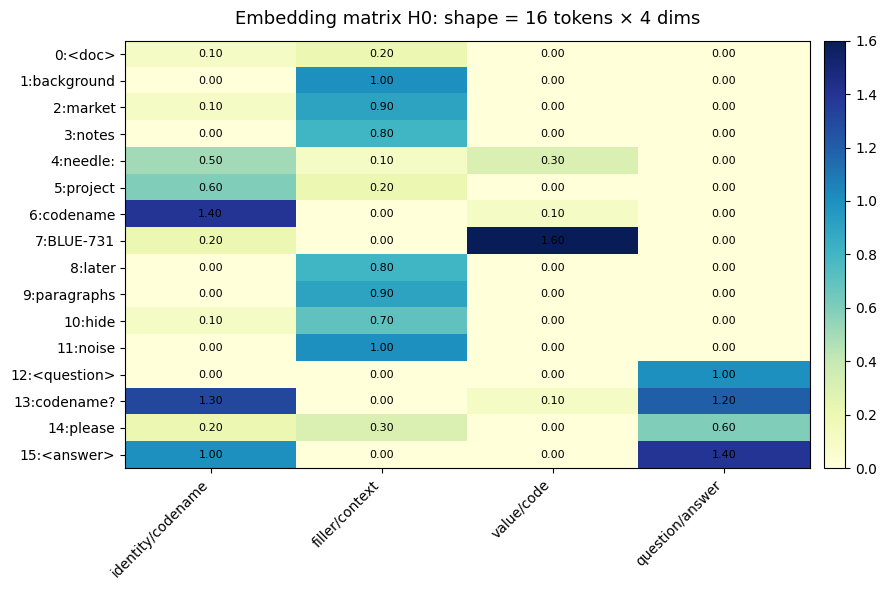

,identity/codename,filler/context,value/code,question/answer
0:<doc>,0.1,0.2,0.0,0.0
1:background,0.0,1.0,0.0,0.0
2:market,0.1,0.9,0.0,0.0
3:notes,0.0,0.8,0.0,0.0
4:needle:,0.5,0.1,0.3,0.0
5:project,0.6,0.2,0.0,0.0
6:codename,1.4,0.0,0.1,0.0
7:BLUE-731,0.2,0.0,1.6,0.0
8:later,0.0,0.8,0.0,0.0
9:paragraphs,0.0,0.9,0.0,0.0


In [4]:
embedding_table = {
    "<doc>":       [0.1, 0.2, 0.0, 0.0],
    "background": [0.0, 1.0, 0.0, 0.0],
    "market":     [0.1, 0.9, 0.0, 0.0],
    "notes":      [0.0, 0.8, 0.0, 0.0],
    "needle:":    [0.5, 0.1, 0.3, 0.0],
    "project":    [0.6, 0.2, 0.0, 0.0],
    "codename":   [1.4, 0.0, 0.1, 0.0],
    "BLUE-731":   [0.2, 0.0, 1.6, 0.0],
    "later":      [0.0, 0.8, 0.0, 0.0],
    "paragraphs": [0.0, 0.9, 0.0, 0.0],
    "hide":       [0.1, 0.7, 0.0, 0.0],
    "noise":      [0.0, 1.0, 0.0, 0.0],
    "<question>": [0.0, 0.0, 0.0, 1.0],
    "codename?":  [1.3, 0.0, 0.1, 1.2],
    "please":     [0.2, 0.3, 0.0, 0.6],
    "<answer>":   [1.0, 0.0, 0.0, 1.4],
}

H0 = np.array([embedding_table[t] for t in tokens], dtype=float)
dims = ["identity/codename", "filler/context", "value/code", "question/answer"]

show_matrix(H0, row_labels=[f"{i}:{t}" for i, t in enumerate(tokens)], col_labels=dims,
            title="Embedding matrix H0: shape = 16 tokens × 4 dims", figsize=(9, 6), cmap="YlGnBu")

display(pd.DataFrame(H0, columns=dims, index=[f"{i}:{t}" for i, t in enumerate(tokens)]))

## 4. mHC pre-block mixing: prepare the attention input

DeepSeek‑V4 strengthens residual connections with **mHC**.

The paper’s update is:

\[
X_{l+1} = B_l X_l + C_l F_l(A_l X_l)
\]

Meaning:

1. `X_l` is not one residual stream. It is multiple residual lanes.
2. `A_l X_l` mixes lanes into the normal layer input.
3. `F_l(...)` is the actual sublayer, like CSA/HCA attention or MoE.
4. `B_l X_l` preserves old information using a stable residual mapping.
5. `C_l F_l(...)` injects the new layer output.

In real DeepSeek‑V4, `n_hc = 4`, so we use 4 lanes here too.

### Attention input after mHC pre-mixing

,identity/codename,filler/context,value/code,question/answer
0:<doc>,0.084,0.153,0.000,0.011
1:background,0.001,0.767,0.000,0.000
2:market,0.076,0.696,0.000,0.000
3:notes,0.001,0.619,0.000,0.000
4:needle:,0.382,0.083,0.230,0.000
5:project,0.463,0.154,0.002,0.000
6:codename,1.076,0.002,0.076,0.000
7:BLUE-731,0.164,0.000,1.225,0.000
8:later,0.002,0.612,0.013,0.000
9:paragraphs,0.000,0.695,0.000,0.000


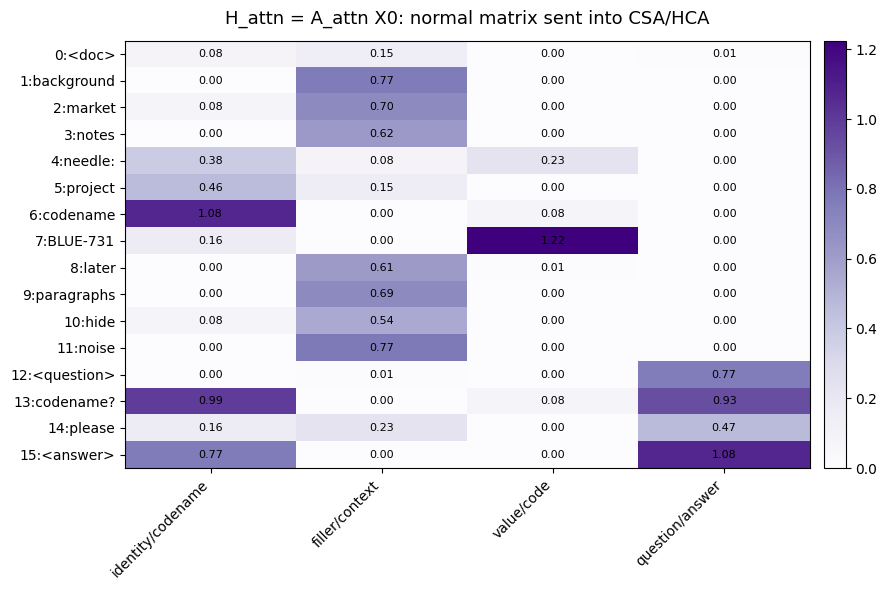

In [5]:
n, d = H0.shape
n_hc = 4

X0 = np.zeros((n, n_hc, d))
X0[:, 0, :] = H0
X0[:, 1, :] = 0.25 * H0
X0[:, 2, :] = 0.10 * np.roll(H0, 1, axis=0)
X0[:, 3, :] = 0.0

A_attn = np.array([0.72, 0.18, 0.08, 0.02])
H_attn = np.einsum("h,nhd->nd", A_attn, X0)

display(Markdown("### Attention input after mHC pre-mixing"))
display(pd.DataFrame(H_attn, columns=dims, index=[f"{i}:{t}" for i, t in enumerate(tokens)]).round(3))

show_matrix(H_attn, row_labels=[f"{i}:{t}" for i, t in enumerate(tokens)], col_labels=dims,
            title="H_attn = A_attn X0: normal matrix sent into CSA/HCA", figsize=(9, 6), cmap="Purples")

## 5. mHC residual matrix `B`: why it is stable

The paper constrains `B_l` to a **doubly stochastic matrix**:

- every row sums to 1
- every column sums to 1
- all entries are non-negative

This makes the residual transform non-expansive, which helps signal stability in very deep models.

Below we create a raw 4×4 matrix and apply a Sinkhorn-style projection, matching the paper’s idea.

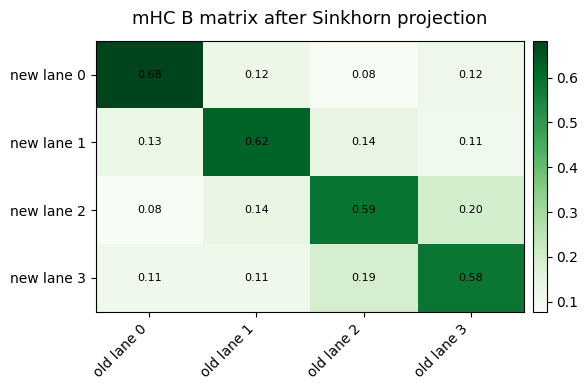

,row sum,column sum
lane 0,1.0,1.0
lane 1,1.0,1.0
lane 2,1.0,1.0
lane 3,1.0,1.0


In [6]:
raw_B = np.array([
    [ 2.0,  0.1, -0.4,  0.0],
    [ 0.2,  1.6,  0.1, -0.2],
    [-0.3,  0.1,  1.5,  0.4],
    [ 0.0, -0.2,  0.3,  1.4],
])
B = sinkhorn(raw_B, iters=20)

show_matrix(B, row_labels=[f"new lane {i}" for i in range(n_hc)],
            col_labels=[f"old lane {i}" for i in range(n_hc)],
            title="mHC B matrix after Sinkhorn projection", figsize=(6, 4), cmap="Greens")

display(pd.DataFrame({
    "row sum": B.sum(axis=1),
    "column sum": B.sum(axis=0),
}, index=[f"lane {i}" for i in range(n_hc)]).round(6))

# 6. CSA: Compressed Sparse Attention

CSA has the clearest “retrieval” behavior.

For each query token, CSA roughly does:

1. Compress every `m=4` KV tokens into one compressed memory block.
2. Use a small lightning indexer to score old compressed blocks.
3. Keep only top-k blocks.
4. Add recent uncompressed sliding-window KV tokens.
5. Run shared-KV multi-query attention on this small set.

In the real model, top-k is 512 for Flash and 1024 for Pro.  
Here, top-k is 1 so the selected block is visually obvious.

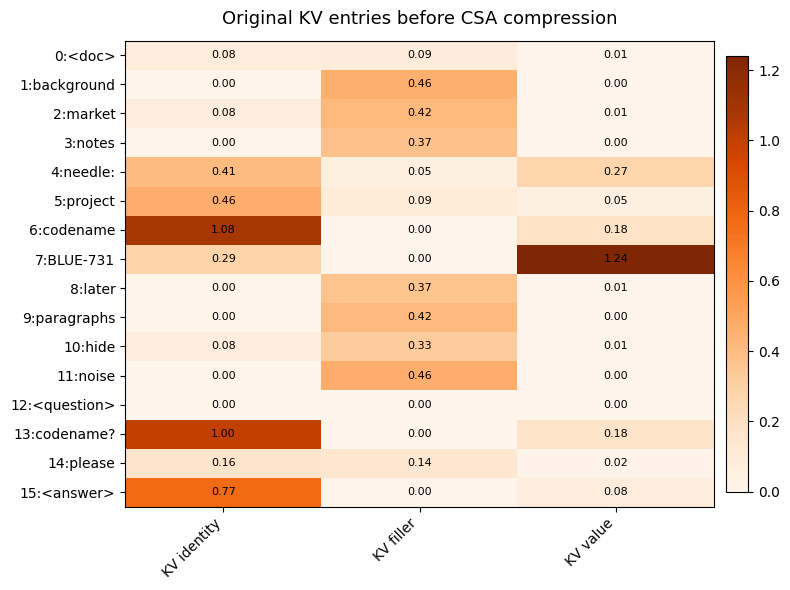

,KV identity,KV filler,KV value
0:<doc>,0.084,0.092,0.008
1:background,0.001,0.460,0.000
2:market,0.076,0.418,0.008
3:notes,0.001,0.372,0.000
4:needle:,0.405,0.050,0.268
5:project,0.463,0.092,0.049
6:codename,1.083,0.001,0.184
7:BLUE-731,0.287,0.000,1.241
8:later,0.003,0.367,0.013
9:paragraphs,0.000,0.417,0.000


In [7]:
W_kv = np.array([
    [1.0, 0.0, 0.1],
    [0.0, 0.6, 0.0],
    [0.1, 0.0, 1.0],
    [0.0, 0.0, 0.0],
])
kv_dims = ["KV identity", "KV filler", "KV value"]

C = H_attn @ W_kv

show_matrix(C, row_labels=[f"{i}:{t}" for i, t in enumerate(tokens)], col_labels=kv_dims,
            title="Original KV entries before CSA compression", figsize=(8, 6), cmap="Oranges")

display(pd.DataFrame(C, columns=kv_dims, index=[f"{i}:{t}" for i, t in enumerate(tokens)]).round(3))

## 6.1 CSA compression: every 4 tokens become 1 memory block

With `m = 4`, the 16-token sequence becomes 4 compressed blocks:

- block 0: tokens 0–3
- block 1: tokens 4–7 ← contains `needle: project codename BLUE-731`
- block 2: tokens 8–11
- block 3: tokens 12–15 ← current question/answer block

For the query at position 15, CSA only uses preceding compressed blocks: block 0, block 1, block 2.

The paper’s exact CSA uses two KV streams and per-dimension compression weights.  
This notebook uses one KV stream with softmax weights so the idea is easy to see numerically.

,block,token positions,tokens,compressed KV
0,0,0-3,<doc> background market notes,"[0.041, 0.338, 0.004]"
1,1,4-7,needle: project codename BLUE-731,"[0.633, 0.025, 0.468]"
2,2,8-11,later paragraphs hide noise,"[0.021, 0.392, 0.005]"
3,3,12-15,<question> codename? please <answer>,"[0.68, 0.022, 0.1]"


,block,position,token,compression weight
0,0,0,<doc>,0.243
1,0,1,background,0.248
2,0,2,market,0.268
3,0,3,notes,0.241
4,1,4,needle:,0.182
5,1,5,project,0.173
6,1,6,codename,0.369
7,1,7,BLUE-731,0.276
8,2,8,later,0.244
9,2,9,paragraphs,0.245


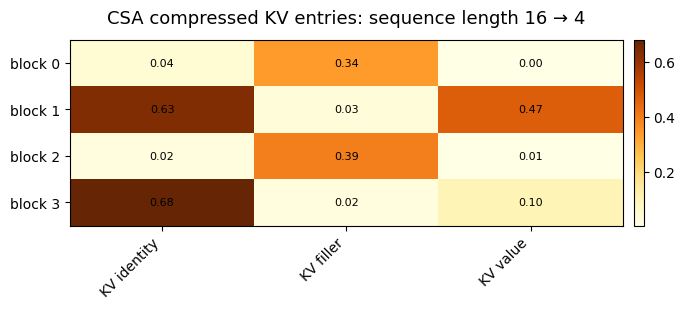

In [8]:
m = 4

W_z = np.array([[1.2], [0.2], [0.7], [0.0]])
Z = H_attn @ W_z

compressed = []
block_rows = []
token_weight_rows = []

for block_id, start in enumerate(range(0, n, m)):
    end = min(start + m, n)
    block_tokens = tokens[start:end]
    w = softmax(Z[start:end, 0])
    comp = (w[:, None] * C[start:end]).sum(axis=0)
    compressed.append(comp)
    block_rows.append({
        "block": block_id,
        "token positions": f"{start}-{end-1}",
        "tokens": " ".join(block_tokens),
        "compressed KV": np.round(comp, 3),
    })
    for local_i, pos in enumerate(range(start, end)):
        token_weight_rows.append({
            "block": block_id,
            "position": pos,
            "token": tokens[pos],
            "compression weight": w[local_i],
        })

C_comp = np.array(compressed)

display(pd.DataFrame(block_rows))
display(pd.DataFrame(token_weight_rows).round(3))

show_matrix(C_comp, row_labels=[f"block {i}" for i in range(len(C_comp))],
            col_labels=kv_dims,
            title="CSA compressed KV entries: sequence length 16 → 4", figsize=(7, 3.2), cmap="YlOrBr")

## 6.2 Lightning indexer: score compressed blocks for the answer token

Now focus on the final token:

`<answer>` at position 15.

It asks: “Which old memory block is relevant to the current query?”

The query contains the idea “codename,” so the correct compressed block should be block 1, because block 1 contains:

`needle: project codename BLUE-731`

,block,tokens in block,index score
0,0,<doc> background market notes,0.068
1,1,needle: project codename BLUE-731,1.030
2,2,later paragraphs hide noise,0.034


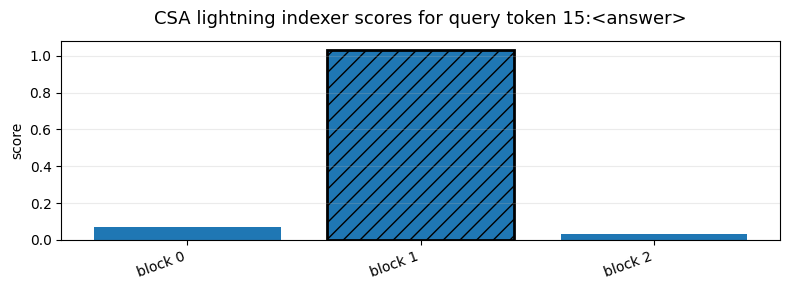

**Selected top-1 compressed block:** block `1` = `needle: project codename BLUE-731`

In [9]:
query_pos = 15
query_token = tokens[query_pos]

W_q_index = np.array([
    [1.0, 0.0, 0.0],
    [0.0, 0.2, 0.0],
    [0.0, 0.0, 0.6],
    [0.8, 0.0, 0.0],
])
q_index = H_attn[query_pos] @ W_q_index

visible_blocks = list(range(query_pos // m))
index_scores = np.maximum(C_comp[visible_blocks] @ q_index, 0.0)

score_df = pd.DataFrame({
    "block": visible_blocks,
    "tokens in block": [" ".join(tokens[b*m:(b+1)*m]) for b in visible_blocks],
    "index score": index_scores,
})
display(score_df.round(3))

selected_block = visible_blocks[int(np.argmax(index_scores))]
show_bar([f"block {b}" for b in visible_blocks], index_scores,
         title=f"CSA lightning indexer scores for query token {query_pos}:{query_token}",
         ylabel="score", highlight=visible_blocks.index(selected_block))

display(Markdown(f"**Selected top-1 compressed block:** block `{selected_block}` = `{score_df.loc[score_df.block == selected_block, 'tokens in block'].iloc[0]}`"))

## 6.3 Add sliding window: keep the local question exact

Compressed memory is good for old context, but it can lose exact local wording.

So CSA also adds recent uncompressed KV tokens.

For the answer token, the local window is:

`<question> codename? please`

That gives exact local intent: “the user asks for the codename.”

,KV identity,KV filler,KV value
compressed block 1,0.633,0.025,0.468
12:<question>,0.000,0.005,0.000
13:codename?,1.002,0.000,0.176
14:please,0.163,0.138,0.017


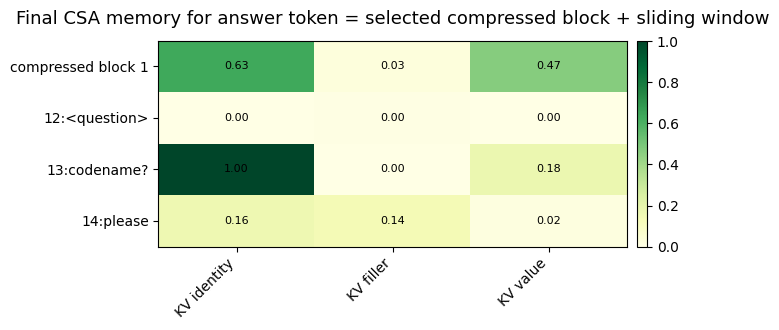

In [10]:
n_win_toy = 3
window_positions = list(range(query_pos - n_win_toy, query_pos))

selected_compressed_kv = C_comp[selected_block]
sliding_kv = C[window_positions]

final_kv = np.vstack([selected_compressed_kv, sliding_kv])
final_labels = [f"compressed block {selected_block}"] + [f"{i}:{tokens[i]}" for i in window_positions]

display(pd.DataFrame(final_kv, columns=kv_dims, index=final_labels).round(3))

show_matrix(final_kv, row_labels=final_labels, col_labels=kv_dims,
            title="Final CSA memory for answer token = selected compressed block + sliding window",
            figsize=(7, 3.4), cmap="YlGn")

## 6.4 Core attention over the small final memory

Now the answer token attends to only 4 KV entries:

1. selected compressed long-range block
2. `<question>`
3. `codename?`
4. `please`

This is the key efficiency win.

A normal full attention layer would read all previous tokens.  
CSA reads a tiny selected set.

,memory entry,logit,attention weight
0,compressed block 1,0.595,0.277
1,12:<question>,0.000,0.153
2,13:codename?,0.942,0.392
3,14:please,0.154,0.178


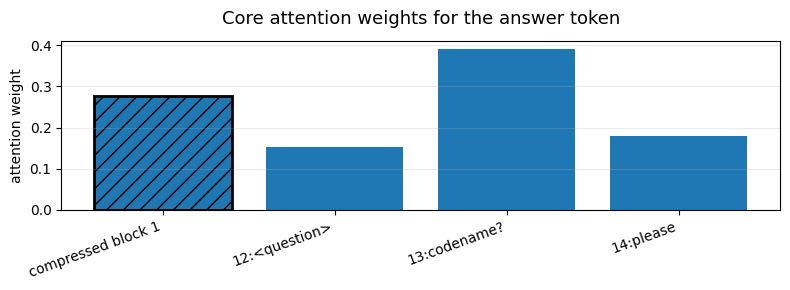

### CSA output vector for the answer token

,identity/codename,filler/context,value/code,question/answer
15:<answer>,0.597,0.032,0.202,0.0


In [11]:
q_core = q_index.copy()
attention_logits = final_kv @ q_core / np.sqrt(final_kv.shape[1])
attention_weights = softmax(attention_logits)
attn_out_c = attention_weights @ final_kv

W_out = np.array([
    [1.0, 0.0, 0.0, 0.0],
    [0.0, 1.0, 0.0, 0.0],
    [0.0, 0.0, 1.0, 0.0],
])
attn_out = attn_out_c @ W_out

attn_df = pd.DataFrame({
    "memory entry": final_labels,
    "logit": attention_logits,
    "attention weight": attention_weights,
})
display(attn_df.round(3))

show_bar(final_labels, attention_weights,
         title="Core attention weights for the answer token",
         ylabel="attention weight", highlight=0)

display(Markdown("### CSA output vector for the answer token"))
display(pd.DataFrame([attn_out], columns=dims, index=[f"{query_pos}:{query_token}"]).round(3))

# 7. HCA: Heavily Compressed Attention alternative

HCA is the cheaper global-view path.

CSA does:

\[
\text{moderate compression} \rightarrow \text{top-k sparse retrieval}
\]

HCA does:

\[
\text{heavy compression} \rightarrow \text{dense attention over compressed blocks}
\]

In the real paper:

- HCA uses `m′ = 128`, much larger than CSA’s `m = 4`.
- HCA does not use the sparse top-k selector.
- HCA still adds a sliding-window branch for exact recent tokens.

Here we use toy `m′ = 8`.

,HCA block,positions,tokens,compressed KV
0,0,0-7,<doc> background market notes needle: project ...,"[0.449, 0.123, 0.323]"
1,1,8-15,later paragraphs hide noise <question> codenam...,"[0.442, 0.156, 0.066]"


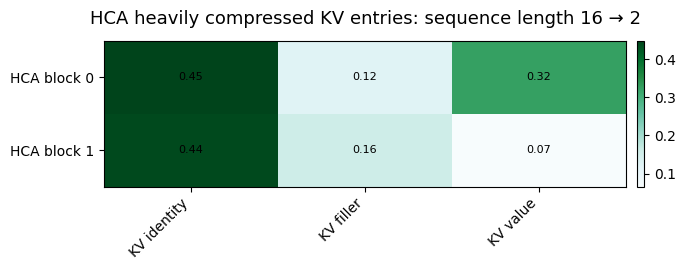

,memory entry,attention weight
HCA block 0,HCA block 0,0.244
12:<question>,12:<question>,0.160
13:codename?,13:codename?,0.410
14:please,14:please,0.186


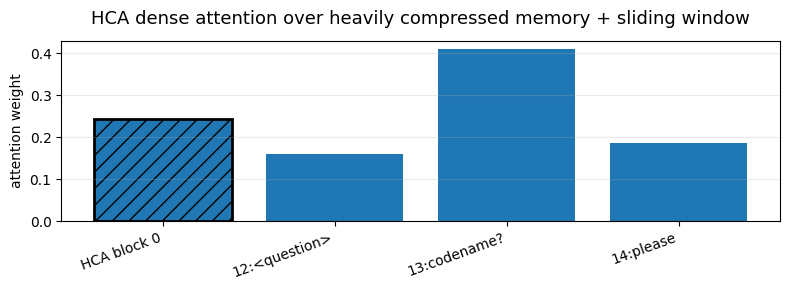

### HCA output vector for the answer token

,identity/codename,filler/context,value/code,question/answer
15:<answer>,0.551,0.056,0.154,0.0


In [12]:
m_prime_toy = 8

hca_comp = []
hca_rows = []
for block_id, start in enumerate(range(0, n, m_prime_toy)):
    end = min(start + m_prime_toy, n)
    w = softmax(Z[start:end, 0])
    comp = (w[:, None] * C[start:end]).sum(axis=0)
    hca_comp.append(comp)
    hca_rows.append({
        "HCA block": block_id,
        "positions": f"{start}-{end-1}",
        "tokens": " ".join(tokens[start:end]),
        "compressed KV": np.round(comp, 3),
    })
C_hca = np.array(hca_comp)

display(pd.DataFrame(hca_rows))

visible_hca_blocks = list(range(query_pos // m_prime_toy))
hca_final_kv = np.vstack([C_hca[visible_hca_blocks], sliding_kv])
hca_labels = [f"HCA block {b}" for b in visible_hca_blocks] + [f"{i}:{tokens[i]}" for i in window_positions]

hca_logits = hca_final_kv @ q_core / np.sqrt(hca_final_kv.shape[1])
hca_weights = softmax(hca_logits)
hca_out_c = hca_weights @ hca_final_kv
hca_out = hca_out_c @ W_out

show_matrix(C_hca, row_labels=[f"HCA block {i}" for i in range(len(C_hca))],
            col_labels=kv_dims,
            title="HCA heavily compressed KV entries: sequence length 16 → 2", figsize=(7, 2.8), cmap="BuGn")

display(pd.DataFrame({
    "memory entry": hca_labels,
    "attention weight": hca_weights,
}, index=hca_labels).round(3))

show_bar(hca_labels, hca_weights,
         title="HCA dense attention over heavily compressed memory + sliding window",
         ylabel="attention weight", highlight=0)

display(Markdown("### HCA output vector for the answer token"))
display(pd.DataFrame([hca_out], columns=dims, index=[f"{query_pos}:{query_token}"]).round(3))

## 8. CSA vs HCA, explained with the same sequence

For this example:

- **CSA** selects block 1 exactly because the lightning indexer detects the hidden `codename BLUE-731` block.
- **HCA** sees a much bigger compressed block containing the needle, but it is coarser.
- **Sliding window** preserves the exact local question.

That is why the paper combines CSA and HCA in a hybrid design.

### Master sentence

> CSA is precise long-range retrieval. HCA is cheap global context. Sliding window is exact local memory.

In [13]:
comparison = pd.DataFrame([
    ["CSA", "m=4 in paper and notebook", "yes, top-k", "selected block 1", "precise retrieval of the codename block"],
    ["HCA", "m′=128 in paper, 8 here", "no", "attends to block 0", "cheap global summary, less detailed"],
    ["Sliding window", "128 in paper, 3 here", "no", "<question> codename? please", "keeps local question exact"],
], columns=["Path", "Compression", "Sparse selector?", "What happened here", "Why it matters"])
display(comparison)

,Path,Compression,Sparse selector?,What happened here,Why it matters
0,CSA,m=4 in paper and notebook,"yes, top-k",selected block 1,precise retrieval of the codename block
1,HCA,"m′=128 in paper, 8 here",no,attends to block 0,"cheap global summary, less detailed"
2,Sliding window,"128 in paper, 3 here",no,<question> codename? please,keeps local question exact


# 9. mHC residual update after attention

Now the CSA attention output is injected back into the residual lanes.

Instead of:

\[
x_{l+1} = x_l + F(x_l)
\]

mHC uses:

\[
X_{l+1} = B_l X_l + C_lF_l(A_lX_l)
\]

For this toy block:

- `B X0` carries old information through stable residual lanes.
- `C * attention_output` injects the new attention information.

### For each token, which compressed block did CSA select?

,position,token,selected compressed block
0,0,<doc>,NaN
1,1,background,NaN
2,2,market,NaN
3,3,notes,NaN
4,4,needle:,0.0
5,5,project,0.0
6,6,codename,0.0
7,7,BLUE-731,0.0
8,8,later,0.0
9,9,paragraphs,0.0


### Attention output for answer token

,identity/codename,filler/context,value/code,question/answer
15:<answer>,0.597,0.032,0.202,0.0


### Four mHC lanes after attention update for answer token

,identity/codename,filler/context,value/code,question/answer
lane 0,1.252,0.031,0.181,1.003
lane 1,0.554,0.019,0.091,0.404
lane 2,0.273,0.026,0.050,0.193
lane 3,0.206,0.009,0.020,0.210


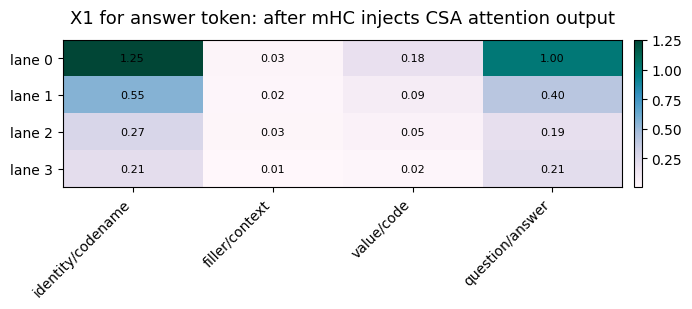

In [14]:
O_attn = np.zeros((n, d))
selected_for_each_token = []

for t in range(n):
    q_t = H_attn[t] @ W_q_index
    visible = list(range(t // m))
    local = list(range(max(0, t - n_win_toy), t))

    if len(visible) > 0:
        scores = np.maximum(C_comp[visible] @ q_t, 0.0)
        sel = visible[int(np.argmax(scores))]
        selected_for_each_token.append(sel)
        K = np.vstack([C_comp[sel], C[local]]) if local else C_comp[[sel]]
    else:
        selected_for_each_token.append(None)
        K = C[local] if local else np.zeros((1, C.shape[1]))

    logits_t = K @ q_t / np.sqrt(C.shape[1])
    w = softmax(logits_t)
    out_c = w @ K
    O_attn[t] = out_c @ W_out

C_post = np.array([0.90, 0.45, 0.25, 0.10])

residual_part = np.einsum("ab,nbd->nad", B, X0)
injected_part = C_post[None, :, None] * O_attn[:, None, :]
X1 = residual_part + injected_part

display(Markdown("### For each token, which compressed block did CSA select?"))
display(pd.DataFrame({
    "position": range(n),
    "token": tokens,
    "selected compressed block": selected_for_each_token,
}))

display(Markdown("### Attention output for answer token"))
display(pd.DataFrame([O_attn[query_pos]], columns=dims, index=[f"{query_pos}:{query_token}"]).round(3))

display(Markdown("### Four mHC lanes after attention update for answer token"))
display(pd.DataFrame(X1[query_pos], columns=dims, index=[f"lane {i}" for i in range(n_hc)]).round(3))

show_matrix(X1[query_pos], row_labels=[f"lane {i}" for i in range(n_hc)], col_labels=dims,
            title="X1 for answer token: after mHC injects CSA attention output",
            figsize=(7, 3.2), cmap="PuBuGn")

# 10. DeepSeekMoE feed-forward block

After attention, the model enters the feed-forward layer.

DeepSeek‑V4 uses **DeepSeekMoE**:

- one shared expert
- many routed experts
- only a few routed experts activated per token

Real model:

- Flash: `1 shared + 256 routed`, activate `6`
- Pro: `1 shared + 384 routed`, activate `6`

Toy model:

- `1 shared + 4 routed`, activate `2`

The key idea:

> MoE gives large parameter capacity without paying for every expert on every token.

### MoE input H_ffn after mHC pre-mixing

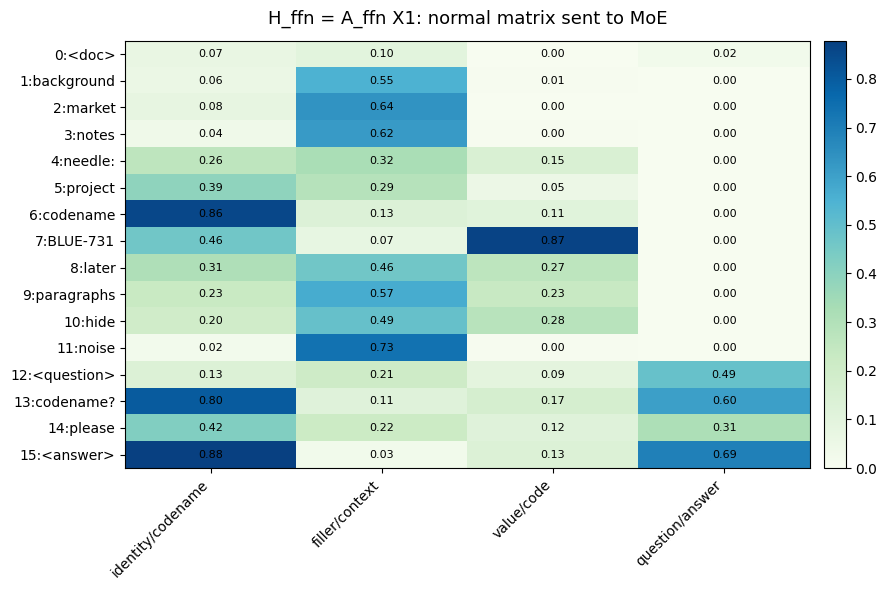

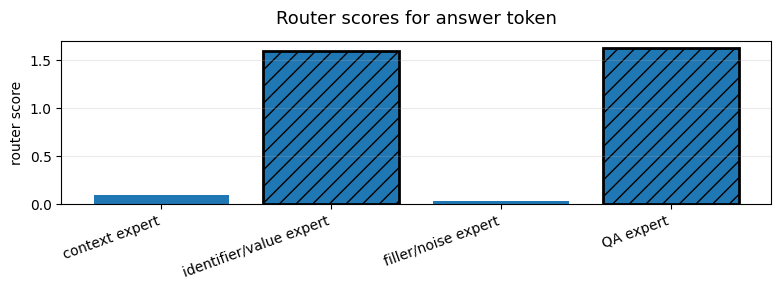

,context expert,identifier/value expert,filler/noise expert,QA expert
15:<answer>,0.098,1.595,0.032,1.623


**Top-2 routed experts for the answer token:** QA expert, identifier/value expert

In [15]:
A_ffn = np.array([0.55, 0.25, 0.15, 0.05])
H_ffn = np.einsum("h,nhd->nd", A_ffn, X1)

display(Markdown("### MoE input H_ffn after mHC pre-mixing"))
show_matrix(H_ffn, row_labels=[f"{i}:{t}" for i, t in enumerate(tokens)], col_labels=dims,
            title="H_ffn = A_ffn X1: normal matrix sent to MoE", figsize=(9, 6), cmap="GnBu")

expert_names = ["context expert", "identifier/value expert", "filler/noise expert", "QA expert"]

W_router = np.array([
    [0.1, 1.4, 0.0, 0.7],
    [0.4, 0.0, 1.2, 0.0],
    [0.0, 1.2, 0.0, 0.3],
    [0.0, 0.3, 0.0, 1.4],
])
router_scores = H_ffn @ W_router

answer_scores = router_scores[query_pos]
top2 = np.argsort(answer_scores)[-2:][::-1]
show_bar(expert_names, answer_scores, title="Router scores for answer token", ylabel="router score", highlight=list(top2))

display(pd.DataFrame([answer_scores], columns=expert_names, index=[f"{query_pos}:{query_token}"]).round(3))
display(Markdown("**Top-2 routed experts for the answer token:** " + ", ".join([expert_names[i] for i in top2])))

## 10.1 Expert computation

Each selected expert transforms the token differently.

For this example, the final answer token routes to:

1. **QA expert**: because it is answering a question.
2. **identifier/value expert**: because the needed memory is a codename/value.

Then the outputs are mixed using router gate weights.

,position,token,expert 1,gate 1,expert 2,gate 2
0,0,<doc>,filler/noise expert,0.504,identifier/value expert,0.496
1,1,background,filler/noise expert,0.607,context expert,0.393
2,2,market,filler/noise expert,0.623,context expert,0.377
3,3,notes,filler/noise expert,0.620,context expert,0.380
4,4,needle:,identifier/value expert,0.540,filler/noise expert,0.460
5,5,project,identifier/value expert,0.566,filler/noise expert,0.434
6,6,codename,identifier/value expert,0.667,QA expert,0.333
7,7,BLUE-731,identifier/value expert,0.751,QA expert,0.249
8,8,later,identifier/value expert,0.549,filler/noise expert,0.451
9,9,paragraphs,filler/noise expert,0.522,identifier/value expert,0.478


### MoE output for answer token

,identity/codename,filler/context,value/code,question/answer
15:<answer>,0.813,0.005,0.114,0.545


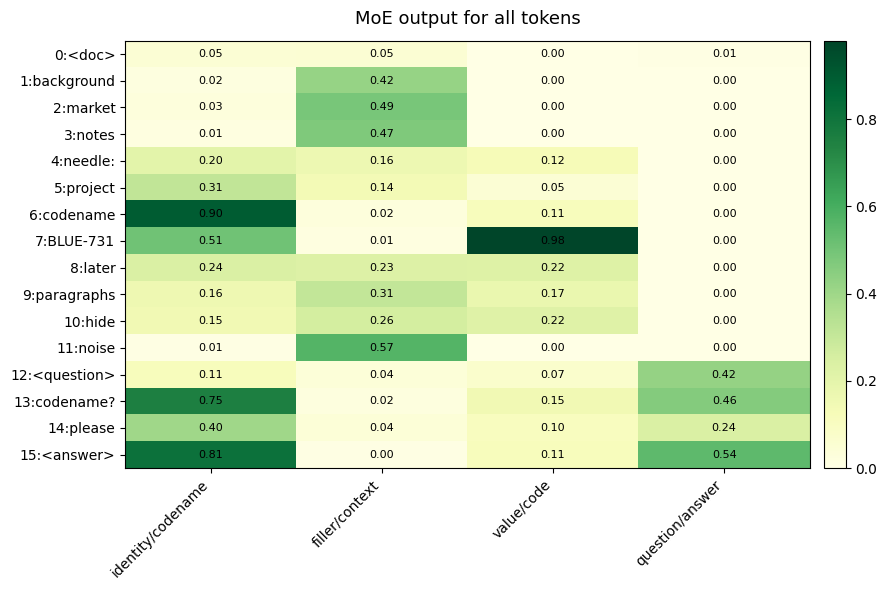

In [16]:
def expert_out(h, idx):
    mats = [
        np.diag([0.5, 0.5, 0.2, 0.2]),
        np.diag([1.2, 0.1, 1.3, 0.2]),
        np.diag([0.1, 0.8, 0.1, 0.1]),
        np.diag([0.5, 0.1, 0.3, 1.2]),
    ]
    return h @ mats[idx]

O_moe = np.zeros_like(H_ffn)
route_rows = []

for i, h in enumerate(H_ffn):
    scores_i = router_scores[i]
    top = np.argsort(scores_i)[-2:][::-1]
    gates = softmax(scores_i[top])
    out = 0.08 * h
    for gate, expert_id in zip(gates, top):
        out += gate * expert_out(h, expert_id)
    O_moe[i] = out
    route_rows.append({
        "position": i,
        "token": tokens[i],
        "expert 1": expert_names[top[0]],
        "gate 1": gates[0],
        "expert 2": expert_names[top[1]],
        "gate 2": gates[1],
    })

display(pd.DataFrame(route_rows).round(3))

display(Markdown("### MoE output for answer token"))
display(pd.DataFrame([O_moe[query_pos]], columns=dims, index=[f"{query_pos}:{query_token}"]).round(3))

show_matrix(O_moe, row_labels=[f"{i}:{t}" for i, t in enumerate(tokens)], col_labels=dims,
            title="MoE output for all tokens", figsize=(9, 6), cmap="YlGn")

# 11. mHC residual update after MoE

Now the MoE output is injected back through mHC, exactly like the attention output.

This gives the final block output.

### Four mHC lanes after MoE update for answer token

,identity/codename,filler/context,value/code,question/answer
lane 0,1.700,0.031,0.244,1.264
lane 1,0.931,0.022,0.140,0.674
lane 2,0.578,0.023,0.089,0.425
lane 3,0.458,0.016,0.064,0.373


### Final hidden matrix readout H_final

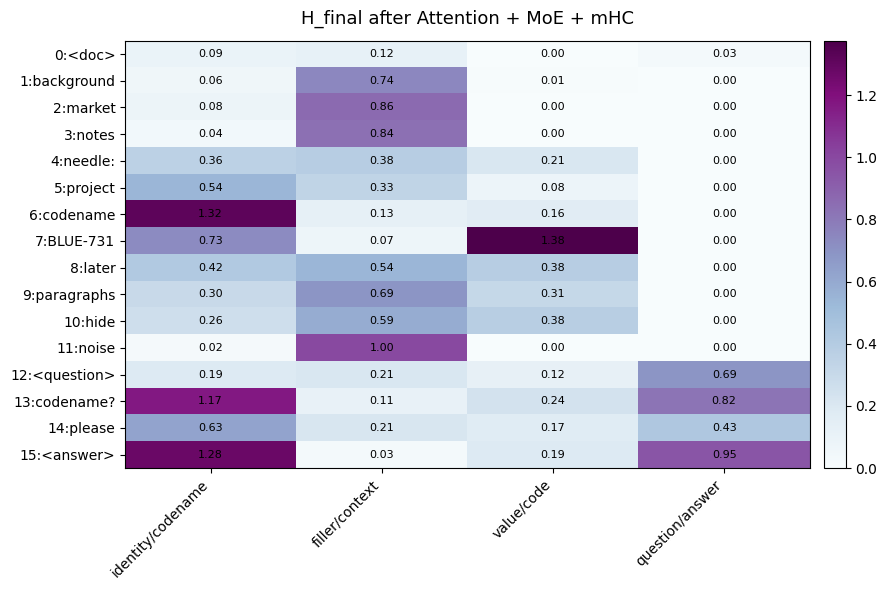

,identity/codename,filler/context,value/code,question/answer
0:<doc>,0.093,0.117,0.000,0.032
1:background,0.061,0.742,0.005,0.000
2:market,0.081,0.864,0.003,0.000
3:notes,0.040,0.837,0.003,0.000
4:needle:,0.356,0.382,0.206,0.000
5:project,0.539,0.335,0.077,0.000
6:codename,1.317,0.127,0.164,0.000
7:BLUE-731,0.729,0.071,1.375,0.000
8:later,0.418,0.540,0.382,0.000
9:paragraphs,0.297,0.690,0.310,0.000


In [17]:
X2 = np.einsum("ab,nbd->nad", B, X1) + C_post[None, :, None] * O_moe[:, None, :]
H_final = np.einsum("h,nhd->nd", A_ffn, X2)

display(Markdown("### Four mHC lanes after MoE update for answer token"))
display(pd.DataFrame(X2[query_pos], columns=dims, index=[f"lane {i}" for i in range(n_hc)]).round(3))

display(Markdown("### Final hidden matrix readout H_final"))
show_matrix(H_final, row_labels=[f"{i}:{t}" for i, t in enumerate(tokens)], col_labels=dims,
            title="H_final after Attention + MoE + mHC", figsize=(9, 6), cmap="BuPu")

display(pd.DataFrame(H_final, columns=dims, index=[f"{i}:{t}" for i, t in enumerate(tokens)]).round(3))

# 12. Prediction head: choose the next token

The prediction head maps the final hidden state to vocabulary logits.

Here the candidate vocabulary is tiny:

- `BLUE-731`
- `project`
- `market`
- `unknown`
- `noise`

The correct answer should be `BLUE-731`.

Because CSA retrieved the compressed block containing `BLUE-731`, the final hidden state has a strong `value/code` signal.

,candidate token,logit,probability
0,BLUE-731,1.232,0.382
1,project,0.641,0.212
3,unknown,0.381,0.163
2,market,0.149,0.129
4,noise,0.019,0.114


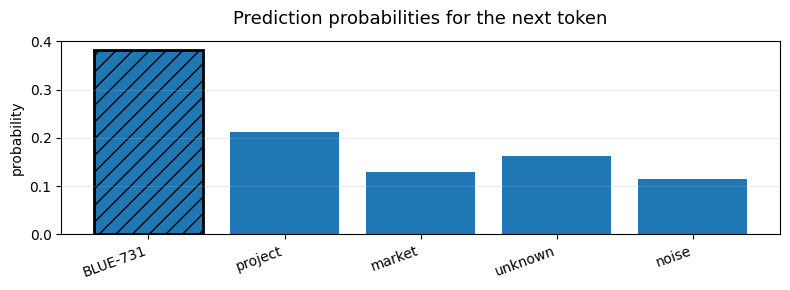

## Predicted next token: `BLUE-731`

In [18]:
answer_vocab = ["BLUE-731", "project", "market", "unknown", "noise"]

W_vocab = np.array([
    [0.2, 0.5, 0.1, 0.0, 0.0],
    [0.0, 0.1, 0.8, 0.1, 0.7],
    [2.2, 0.0, 0.0, 0.0, 0.0],
    [0.6, 0.0, 0.0, 0.4, 0.0],
])

logits = H_final[query_pos] @ W_vocab
probs = softmax(logits)

pred_df = pd.DataFrame({
    "candidate token": answer_vocab,
    "logit": logits,
    "probability": probs,
}).sort_values("probability", ascending=False)

display(pred_df.round(3))
show_bar(answer_vocab, probs, title="Prediction probabilities for the next token", ylabel="probability", highlight=int(np.argmax(probs)))

display(Markdown(f"## Predicted next token: `{answer_vocab[int(np.argmax(probs))]}`"))

# 13. MTP side branch: extra training signal

The paper says DeepSeek‑V4 keeps the Multi-Token Prediction strategy from DeepSeek‑V3.

Main LM training predicts the **next token**.

MTP adds an auxiliary objective that predicts additional future token(s).  
This gives stronger learning signal during training.

In our toy sequence, at position 13:

`codename? → please → <answer>`

A depth-1 MTP side branch can train the model to also anticipate one more future token.

In [19]:
mtp_example = pd.DataFrame([
    ["position 13 token", tokens[13]],
    ["normal LM target", tokens[14]],
    ["MTP extra target", tokens[15]],
], columns=["Item", "Value"])
display(mtp_example)

display(HTML("""
<div style="padding:14px;border:1px solid #b8c6ff;border-radius:10px;background:#f5f7ff;">
<b>Training intuition:</b><br>
LM loss says: from <code>codename?</code>, predict <code>please</code>.<br>
MTP loss says: also learn useful features for predicting <code>&lt;answer&gt;</code> soon after.<br>
This can improve representation learning without changing inference-time flow.
</div>
"""))

,Item,Value
0,position 13 token,codename?
1,normal LM target,please
2,MTP extra target,<answer>


# 14. KV cache intuition for serving

The paper’s inference system uses a heterogeneous KV cache because the attention paths produce different memory types:

- CSA compressed KV
- CSA indexer KV
- HCA compressed KV
- sliding-window KV
- uncompressed tail states waiting for compression

In this toy sequence:

- CSA block size is 4, so compressed blocks cover 4 original tokens.
- HCA block size is 8, so compressed blocks cover 8 original tokens.
- Sliding window keeps the last 3 exact tokens.

,Cache type,Representation,Toy rule,In this example
0,CSA main KV,compressed,1 entry per 4 tokens here,"blocks 0,1,2,3"
1,CSA indexer KV,compressed index keys,used for top-k selection,scores blocks for query
2,HCA KV,heavily compressed,1 entry per 8 tokens here,"blocks 0,1"
3,Sliding-window KV,uncompressed,last 3 exact tokens here,"<question>, codename?, please"
4,Uncompressed tail,state,tokens not ready for compression,depends on current position


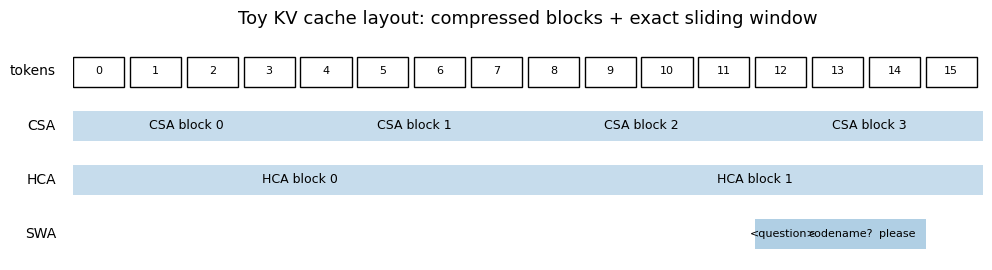

In [20]:
cache_rows = pd.DataFrame([
    ["CSA main KV", "compressed", "1 entry per 4 tokens here", "blocks 0,1,2,3"],
    ["CSA indexer KV", "compressed index keys", "used for top-k selection", "scores blocks for query"],
    ["HCA KV", "heavily compressed", "1 entry per 8 tokens here", "blocks 0,1"],
    ["Sliding-window KV", "uncompressed", "last 3 exact tokens here", "<question>, codename?, please"],
    ["Uncompressed tail", "state", "tokens not ready for compression", "depends on current position"],
], columns=["Cache type", "Representation", "Toy rule", "In this example"])
display(cache_rows)

fig, ax = plt.subplots(figsize=(10, 2.8))
ax.set_xlim(0, 16)
ax.set_ylim(0, 4.2)
ax.axis("off")

for i, tok in enumerate(tokens):
    ax.add_patch(plt.Rectangle((i, 3.2), 0.9, 0.55, fill=False))
    ax.text(i+0.45, 3.48, str(i), ha="center", va="center", fontsize=8)
ax.text(-0.3, 3.48, "tokens", ha="right", va="center", fontsize=10)

for start in range(0, 16, 4):
    ax.add_patch(plt.Rectangle((start, 2.2), 4, 0.55, alpha=0.25))
    ax.text(start+2, 2.48, f"CSA block {start//4}", ha="center", va="center", fontsize=9)
ax.text(-0.3, 2.48, "CSA", ha="right", va="center", fontsize=10)

for start in range(0, 16, 8):
    ax.add_patch(plt.Rectangle((start, 1.2), 8, 0.55, alpha=0.25))
    ax.text(start+4, 1.48, f"HCA block {start//8}", ha="center", va="center", fontsize=9)
ax.text(-0.3, 1.48, "HCA", ha="right", va="center", fontsize=10)

for pos in window_positions:
    ax.add_patch(plt.Rectangle((pos, 0.2), 1, 0.55, alpha=0.35))
    ax.text(pos+0.5, 0.48, tokens[pos], ha="center", va="center", fontsize=8)
ax.text(-0.3, 0.48, "SWA", ha="right", va="center", fontsize=10)

ax.set_title("Toy KV cache layout: compressed blocks + exact sliding window", fontsize=13)
plt.tight_layout()
plt.show()

# 15. Complete end-to-end summary

For the single input sequence, the block did this:

1. **Embedding**: tokens became a `16 × 4` hidden matrix.
2. **mHC pre-mix**: 4 residual lanes were mixed into attention input.
3. **CSA compression**: 16 KV entries became 4 compressed blocks.
4. **Lightning indexer**: the answer query selected block 1.
5. **Sliding window**: exact local question tokens were appended.
6. **Core attention**: the answer token gathered information from selected old memory + local question.
7. **mHC residual update**: attention output was injected into stable residual lanes.
8. **MoE**: answer token routed to QA and identifier/value experts.
9. **Prediction head**: output token became `BLUE-731`.

### Master explanation to say out loud

> DeepSeek‑V4 keeps the Transformer backbone but changes the expensive long-context parts. CSA compresses old KV memory, retrieves only the top relevant compressed blocks, and combines them with an exact sliding window. HCA gives cheaper global context through heavier compression. mHC stabilizes information flow through multiple residual lanes, while DeepSeekMoE routes each token to a few experts for high capacity at lower active compute. In this example, the answer token used CSA to retrieve the old block containing `BLUE-731`, used the sliding window to understand the local question, then MoE and the prediction head produced the final answer.

In [21]:
summary_table = pd.DataFrame([
    ["Input tokens", "16 tokens", "Document + question"],
    ["Embedding H0", str(H0.shape), "Token IDs became vectors"],
    ["mHC X0", str(X0.shape), "4 residual lanes"],
    ["Attention input H_attn", str(H_attn.shape), "Pre-mixed normal matrix"],
    ["CSA compressed KV", str(C_comp.shape), "16 tokens → 4 compressed memory blocks"],
    ["Selected CSA block", selected_block, "Block containing the hidden value"],
    ["CSA final KV for answer", str(final_kv.shape), "Selected block + 3 local tokens"],
    ["CSA answer output", str(attn_out.shape), "Context-aware answer representation"],
    ["After attention mHC X1", str(X1.shape), "Attention injected into residual lanes"],
    ["MoE input H_ffn", str(H_ffn.shape), "Prepared for expert routing"],
    ["MoE output O_moe", str(O_moe.shape), "Sparse expert computation"],
    ["Final hidden H_final", str(H_final.shape), "Block output"],
    ["Prediction", answer_vocab[int(np.argmax(probs))], "Most likely next token"],
], columns=["Stage", "Output", "Meaning"])
display(summary_table)

,Stage,Output,Meaning
0,Input tokens,16 tokens,Document + question
1,Embedding H0,"(16, 4)",Token IDs became vectors
2,mHC X0,"(16, 4, 4)",4 residual lanes
3,Attention input H_attn,"(16, 4)",Pre-mixed normal matrix
4,CSA compressed KV,"(4, 3)",16 tokens → 4 compressed memory blocks
5,Selected CSA block,1,Block containing the hidden value
6,CSA final KV for answer,"(4, 3)",Selected block + 3 local tokens
7,CSA answer output,"(4,)",Context-aware answer representation
8,After attention mHC X1,"(16, 4, 4)",Attention injected into residual lanes
9,MoE input H_ffn,"(16, 4)",Prepared for expert routing
